# Vol-of-Vol — a quantitative teardown 🔬
### A high-VVIX state · conditional vs unconditional forward returns/drawdowns · the decisive VIX+VVIX HAC regression · a block placebo null · a costed long/flat timer · a synthetic incremental-signal control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better_than_the_VIX%3F: Busted](https://img.shields.io/badge/Better_than_the_VIX%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim is **incremental**: VVIX times equity risk *better than the VIX*. Because corr(VIX, VVIX) ≈ 0.41, a univariate VVIX regression is confounded by VIX, so the only honest object is the **partial effect** of VVIX *conditional on VIX*, with HAC inference for the overlapping-window serial correlation. That coefficient, not the raw one, decides the Signal axis — and it fails the bar.

> ⚠️ **Data note.** `^VVIX`, `^VIX`, `SPY` (auto-adjusted) from yfinance, 2007-01-03→2026-06-18, 4,887 days. VVIX/VIX are index levels; SPY is total-return-ish. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vol_of_vol import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
STATE = st.vvix_state(F) if HAVE_REAL else None
print("real vol-tape cache present:", HAVE_REAL,
      "| high-VVIX days:", (0 if STATE is None else int(STATE.sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-01-03', 'end': '2026-06-18', 'days': 4887, 'years': 19.5, 'n_high': 1059, 'frac_high': 21.7, 'h1': (1, 1059, 1.44, 69, 0.99, 67, 2.35, 0.929, -5.37, -4.13), 'h3': (3, 1046, 3.89, 73, 2.92, 73, 3.51, 0.969, -8.75, -7.66), 'inc1': {'corr': 0.41, 'vix_only_t': 1.14, 'vvix_only_t': 2.28, 'vix_t': 0.57, 'vvix_t': 1.57, 'vvix_only_b': 0.59, 'vvix_b': 0.49}, 'inc3': {'corr': 0.41, 'vix_only_t': 0.82, 'vvix_only_t': 1.74, 'vix_t': 0.39, 'vvix_t': 1.12, 'vvix_only_b': 1.27, 'vvix_b': 1.06}, 'robust': [(0.7, 1567, 1.08, 0.56), (0.8, 1059, 1.44, 2.35), (0.9, 556, 1.6, 2.25)], 'trade': {'net_ann': 8.9, 'net_vol': 13.7, 'net_sh': 0.65, 'bh_ann': 12.4, 'bh_vol': 19.6, 'bh_sh': 0.63, 'trades': 414, 'pct_flat': 22}, 'syn': [(0.0, -0.83, -1.52, -0.5), (0.04, -14.16, -15.84, -13.01), (0.1, -17.76, -19.85, -22.82)]}


real vol-tape cache present: True | high-VVIX days: 1059


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Raw 1m Welch **t = 2.35** (positive — *wrong sign* for a sell signal); but VVIX's HAC *t* falls **2.28 → 1.57** once VIX is in the model, and the raw *t* is **0.56** at the 70th-pct threshold (fragile). |
| **Tradability** | `MIRAGE` | Long/flat timer net Sharpe **0.65** vs buy-and-hold **0.63** — a wash; earns **8.9%** vs **12.4%**. |
| **Better than the VIX?** | `BUSTED` | corr(VIX,VVIX) = **0.41**; in the bivariate HAC fit VVIX **t = 1.57** (1m) / **1.12** (3m) — no incremental signal. |

> 💡 In plain words: VVIX looks like a timer in isolation, but it's a 0.4-correlated shadow of the VIX. Strip the VIX out and almost nothing's left — and what *is* left points the wrong way for "spike = sell."

## 1 · The claim, steelmanned

Let $V_t$ = VIX, $W_t$ = VVIX, and $r_{t\to t+H}$ the forward SPY return. The believers' hypotheses:

- **H₁ (VVIX predicts).** $\mathbb{E}[r_{t\to t+H}\mid W_t\ \text{high}] \ne \mathbb{E}[r_{t\to t+H}]$ — and in the bearish direction.
- **H₂ (incremental over VIX).** In $r_{t\to t+H} = \alpha + \beta\,z(V_t) + \gamma\,z(W_t) + \varepsilon$, the partial coefficient $\gamma$ is significant **with $\beta$ in the model** — vol-of-vol adds information the VIX lacks.
- **H₃ (deployable).** The edge survives costs and beats buy-and-hold risk-adjusted.

We find **H₁ half-true, wrong-signed** (high VVIX → *higher* mean return, real drawdown signal), **H₂ rejected** ($\gamma$ HAC *t* = 1.57 once $\beta$ is in), **H₃ rejected** (Sharpe tie). The steelman dies on H₂: *incrementality* is the entire claim, and the partial effect doesn't clear the bar.

## 2 · So what? — why the partial coefficient is the only honest number

With $\mathrm{corr}(z(V), z(W)) \approx 0.41$, a univariate $\hat\gamma^{\text{uni}}$ absorbs the VIX's predictive content through the shared variance — Frisch–Waugh–Lovell makes the bivariate $\hat\gamma$ the coefficient on the part of VVIX **orthogonal to VIX**. That is exactly "better than the VIX." And because daily-sampled $H$-day forward returns overlap, $\varepsilon_t$ is strongly autocorrelated; naïve OLS SEs are far too small. We use **Newey-West** with the lag set to the overlap length $H$, so the *t* on $\hat\gamma$ is HAC-honest. The raw win-rate is the wrong lens twice over: US forward returns are positive most of the time *unconditionally*, and the conditional set sits at crash-recovery dates.

## 3 · How we'd know — the protocol

- **Tape.** `^VVIX`, `^VIX`, `SPY` (auto-adjusted), 2007-01-03→2026-06-18, 4,887 days. VVIX history begins 2007 (covers GFC / 2011 / 2015 / 2018 / 2020).
- **State.** High vol-of-vol = $W_t$ above its trailing **252-day 80th percentile** (causal; no look-ahead).
- **Forward objects.** $H\in\{1,3\}$ months (21/63d): forward return **and** worst peak-to-trough drawdown; enter the close **1 day after** the signal.
- **Null #1 (Welch t).** Conditional vs unconditional overlapping forward mean.
- **Null #2 (block placebo).** 20,000 contiguous-block resamples sized to the state's clustering; $p = \Pr[\text{draw mean} \le \text{conditional mean}]$ (testing for under-performance).
- **The decider (HAC regression).** $r = \alpha + \beta z(V) + \gamma z(W)$ with Newey-West SEs at lag $H$; VIX-only, VVIX-only, and bivariate fits.
- **Costs.** 1-day-lagged long/flat timer, 2 bps one-way per position change, raced gross/net vs buy-and-hold.
- **Positive control.** A synthetic tape where the planted edge lives **only** in the VIX-orthogonal part of VVIX: $\gamma$ must be null at edge 0 and light up for a large edge.

## 4 · The teardown

### 4a · Conditional forward returns — positive, wrong-signed, *t* without the control

Conditional mean forward return (±SE) vs the unconditional base rate (dashed). Positive at both horizons — the high-VVIX set sits at crash-recovery dates, so a naïve Welch *t* is **positive**, the opposite of the bearish thesis.

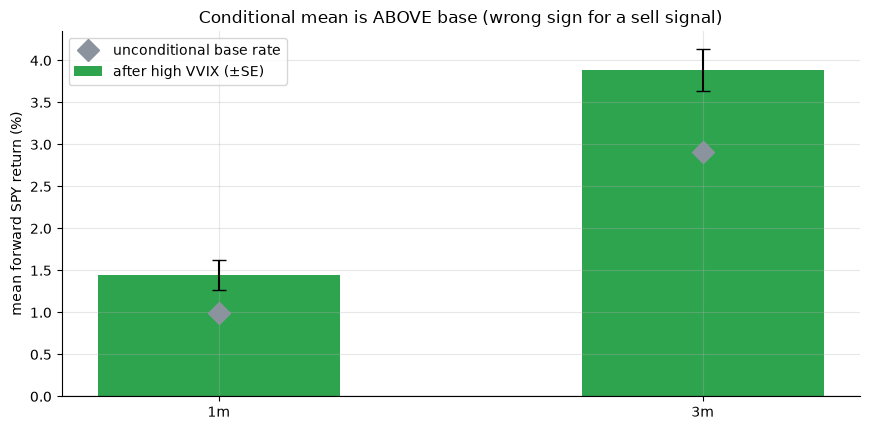

Welch t by horizon: {'1m': 2.35, '3m': 3.51}


In [2]:
hs = [1, 3]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, STATE, m); cm.append(s['cond_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        h = st.TRADING_DAYS[m]; fwd = st.forward_return(F['spy'], h).shift(-1).dropna()
        cond = fwd[STATE.reindex(fwd.index).fillna(False).values]
        ses.append(cond.std(ddof=1)/np.sqrt(len(cond)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100]; bm = [R['h1'][4]/100, R['h3'][4]/100]
    ts = [R['h1'][6], R['h3'][6]]; ses = [0.0024, 0.0040]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='after high VVIX (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Conditional mean is ABOVE base (wrong sign for a sell signal)'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 1m the conditional mean is **+1.44%** vs base **+0.99%** (Welch *t* = 2.35) — *positive*. VVIX peaks at bottoms, and bottoms bounce. As a directional sell signal H₁ is **wrong-signed**; the honest positive content is in the drawdown (4c) and must still beat the VIX (4b).

### 4b · The decisive test — incremental over VIX (HAC regression)

Three Newey-West fits on the aligned sample: VIX-only, VVIX-only, and the bivariate VIX+VVIX. The vol-of-vol thesis requires the **bivariate** VVIX *t* to clear 2.

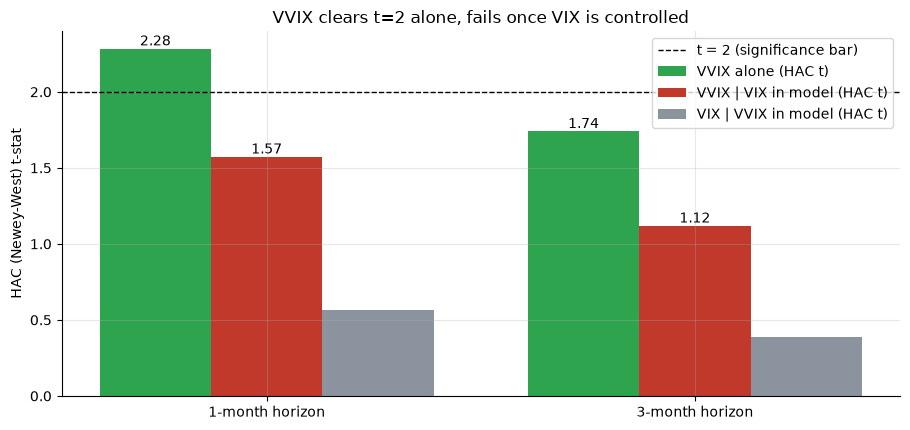

VVIX HAC t — alone vs with VIX: [(2.28, 1.57), (1.74, 1.12)]


In [3]:
hs = [1, 3]
if HAVE_REAL:
    rr = [st.incremental_regression(F, m) for m in hs]
    vvix_only = [r['vvix_only_t'] for r in rr]; vvix_both = [r['vvix_t'] for r in rr]
    vix_both = [r['vix_t'] for r in rr]
else:
    vvix_only = [R['inc1']['vvix_only_t'], R['inc3']['vvix_only_t']]
    vvix_both = [R['inc1']['vvix_t'], R['inc3']['vvix_t']]
    vix_both = [R['inc1']['vix_t'], R['inc3']['vix_t']]
x = np.arange(len(hs)); w = .26
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-w, vvix_only, w, color=GREEN, label='VVIX alone (HAC t)')
ax.bar(x,   vvix_both, w, color=RED, label='VVIX | VIX in model (HAC t)')
ax.bar(x+w, vix_both,  w, color=GREY, label='VIX | VVIX in model (HAC t)')
ax.axhline(2, ls='--', c='k', lw=1, label='t = 2 (significance bar)')
ax.set_xticks(x); ax.set_xticklabels([f'{m}-month horizon' for m in hs])
ax.set_ylabel('HAC (Newey-West) t-stat')
ax.set_title('VVIX clears t=2 alone, fails once VIX is controlled'); ax.legend()
for i in range(len(hs)):
    ax.annotate(f'{vvix_only[i]:.2f}',(i-w,vvix_only[i]),ha='center',va='bottom')
    ax.annotate(f'{vvix_both[i]:.2f}',(i,vvix_both[i]),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('VVIX HAC t — alone vs with VIX:', [(round(a,2),round(b,2)) for a,b in zip(vvix_only,vvix_both)])

> 💡 In plain words: the **green** bars (VVIX alone) clear 2 at 1m (2.28); the **red** bars (VVIX with VIX controlled) sink to 1.57 / 1.12. The orthogonal-to-VIX part of VVIX carries no robust signal. **This single chart is the verdict** — H₂ rejected, "better than the VIX" busted.

### 4c · Robustness + the drawdown bite — neither rescues incrementality

Left: the raw Welch *t* across VVIX-state thresholds — significant only in a narrow tail band (fragile). Right: where the signal genuinely (if weakly) bites — forward drawdowns are deeper after high VVIX. Neither restores an *incremental* edge over VIX.

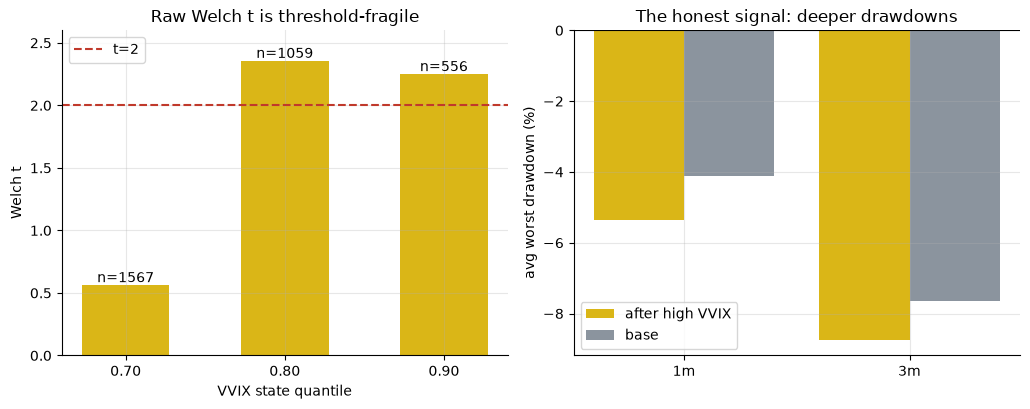

robustness (q, n, cond%, welch t): [(0.7, 1567, 1.08, 0.56), (0.8, 1059, 1.44, 2.35), (0.9, 556, 1.6, 2.25)]


In [4]:
if HAVE_REAL:
    rob = [(q,)+(lambda s:(s['n'],s['cond_mean']*100,s['t']))(st.summarize(F, st.vvix_state(F,q=q),1)) for q in (0.70,0.80,0.90)]
    cdd = [st.summarize(F, STATE, m)['cond_dd']*100 for m in (1,3)]
    bdd = [st.summarize(F, STATE, m)['base_dd']*100 for m in (1,3)]
else:
    rob = [(q,n,c,t) for (q,n,c,t) in R['robust']]
    cdd = [R['h1'][8], R['h3'][8]]; bdd = [R['h1'][9], R['h3'][9]]
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.4,4.2))
qs=[r[0] for r in rob]; tt=[r[3] for r in rob]; ns=[r[1] for r in rob]
a1.bar([f'{q:.2f}' for q in qs], tt, color=AMBER, width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2'); a1.set_ylim(0,2.6)
for i,(t,n) in enumerate(zip(tt,ns)): a1.annotate(f'n={n}',(i,t),ha='center',va='bottom')
a1.set_title('Raw Welch t is threshold-fragile'); a1.set_xlabel('VVIX state quantile'); a1.set_ylabel('Welch t'); a1.legend()
xx=np.arange(2)
a2.bar(xx-.2,cdd,.4,color=AMBER,label='after high VVIX'); a2.bar(xx+.2,bdd,.4,color=GREY,label='base')
a2.set_xticks(xx); a2.set_xticklabels(['1m','3m']); a2.set_ylabel('avg worst drawdown (%)'); a2.axhline(0,c='k',lw=.8)
a2.set_title('The honest signal: deeper drawdowns'); a2.legend()
plt.tight_layout(); plt.show()
print('robustness (q, n, cond%, welch t):', [(r[0], r[1], round(r[2],2), round(r[3],2)) for r in rob])

> 💡 In plain words: drop the bar to the 70th pct and the raw Welch *t* falls to **0.56** — the "significant" number lives only in the extreme tail. The drawdown signal is real (−5.4% vs −4.1% at 1m) but it's a *risk* flag, not a *return* edge, and it's still just **vol** — the VIX flags the same drawdowns.

### 4d · Faithful-engine & incremental-power control — we know the truth here

A synthetic tape where VVIX = a VIX component **plus an independent vol-of-vol component**, and the planted edge is injected **only** into the VIX-orthogonal part. With **zero** edge the bivariate VVIX *t* must stay inside ±2 (no false positive); with a large planted edge it must light up — proving the engine isolates *incremental* signal, not VIX bleed-through.

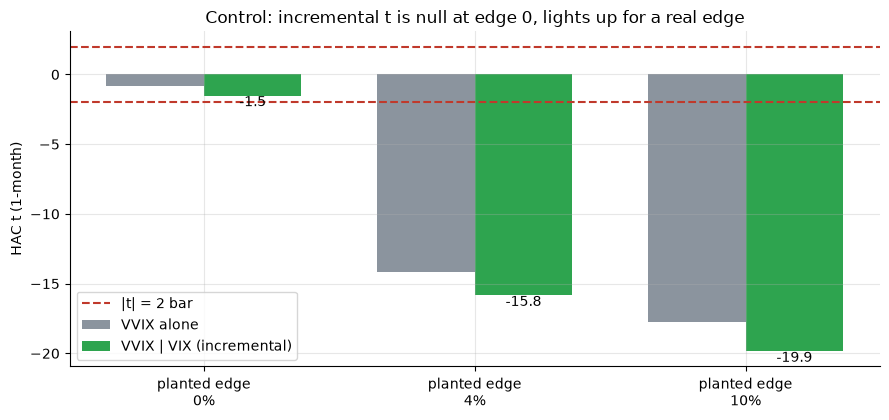

planted +0%: VVIX-only t=-0.83 -> VVIX|VIX t=-1.52
planted +4%: VVIX-only t=-14.16 -> VVIX|VIX t=-15.84
planted +10%: VVIX-only t=-17.76 -> VVIX|VIX t=-19.85


In [5]:
res = []
for edge in (0.0, 0.04, 0.10):
    syn = data.synthetic_tape(edge=edge, seed=374)
    r = st.incremental_regression(syn, 1)
    res.append((edge, r['vvix_only_t'], r['vvix_t']))
labels = [f'planted edge\n{e*100:.0f}%' for e,_,_ in res]
only = [r[1] for r in res]; both = [r[2] for r in res]
x = np.arange(len(res)); w=.36
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-w/2, only, w, color=GREY, label='VVIX alone')
ax.bar(x+w/2, both, w, color=GREEN, label='VVIX | VIX (incremental)')
ax.axhline(-2, ls='--', c=RED, label='|t| = 2 bar'); ax.axhline(2, ls='--', c=RED)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('HAC t (1-month)')
ax.set_title('Control: incremental t is null at edge 0, lights up for a real edge'); ax.legend()
for i,b in enumerate(both): ax.annotate(f'{b:.1f}',(i+w/2,b),ha='center',va='top' if b<0 else 'bottom')
plt.tight_layout(); plt.show()
for e,o,b in res: print(f'planted {e*100:+.0f}%: VVIX-only t={o:.2f} -> VVIX|VIX t={b:.2f}')

> 💡 In plain words: with **no** planted edge the incremental VVIX *t* is **-1.52** (inside ±2 — no false positive); a planted edge drives it to **-15.8 / -19.9** with the correct (negative, drawdown-y) sign. The machinery is honest *and* specifically isolates incrementality. The real-tape incremental *t* of ~1.6 is exactly what **no incremental edge** looks like through this lens.

## 5 · The verdict

- **Signal `WEAK`** — raw 1m Welch *t* = 2.35 (positive, wrong-signed) + a real drawdown flag, but threshold-fragile (*t* = 0.56 at the 70th pct) and, decisively, **non-incremental**: VVIX HAC *t* = 1.57 once VIX is in. Literature support + a non-robust, non-incremental estimate ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`** — long/flat timer net Sharpe 0.65 vs buy-and-hold 0.63 (a wash), earning 8.9% vs 12.4%. No NAV-scale edge.
- **Better than the VIX? `BUSTED`** — corr(VIX,VVIX) = 0.41; the bivariate VVIX *t* is 1.57 (1m) / 1.12 (3m). The raw VVIX edge is mostly the VIX leaking through — vol-of-vol is a redundant cousin of vol.

## 6 · Could you trade it? — the timer, fully costed

The operational read: hold SPY, go flat (cash) when vol-of-vol is high, 1-day lag, 2 bps one-way. Net Sharpe vs buy-and-hold, and what the de-risking actually costs in return.

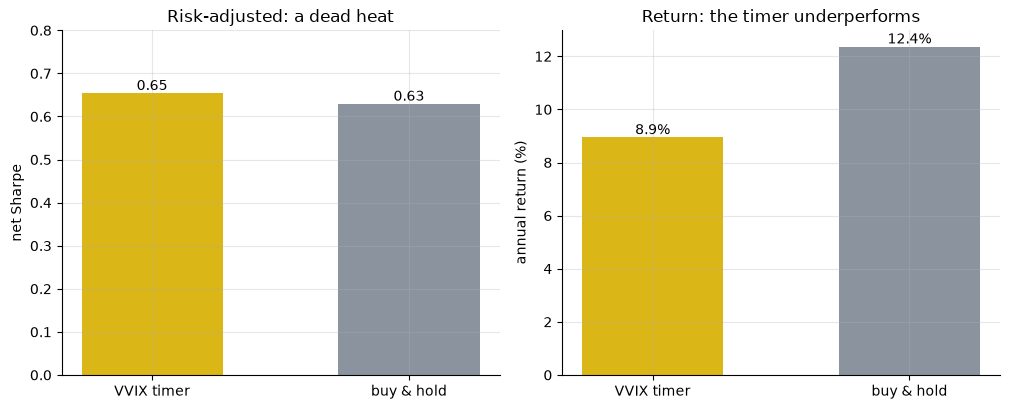

timer: Sharpe 0.65, 8.9%/yr, vol 13.7% (414 trades, 22% flat) | B&H Sharpe 0.63, 12.4%/yr


In [6]:
if HAVE_REAL:
    bt = st.timing_backtest(F, STATE)
    vals = [bt['net_sharpe'], bt['bh_sharpe']]; anns=[bt['net_ann']*100, bt['bh_ann']*100]
    vols=[bt['net_vol']*100, bt['bh_vol']*100]; nt=bt['n_trades']; pf=bt['pct_flat']*100
else:
    t=R['trade']; vals=[t['net_sh'],t['bh_sh']]; anns=[t['net_ann'],t['bh_ann']]
    vols=[t['net_vol'],t['bh_vol']]; nt=t['trades']; pf=t['pct_flat']
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.2,4.2))
a1.bar(['VVIX timer','buy & hold'],vals,color=[AMBER,GREY],width=.55); a1.set_ylim(0,.8)
for i,v in enumerate(vals): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('net Sharpe'); a1.set_title('Risk-adjusted: a dead heat')
a2.bar(['VVIX timer','buy & hold'],anns,color=[AMBER,GREY],width=.55)
for i,v in enumerate(anns): a2.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('annual return (%)'); a2.set_title('Return: the timer underperforms')
plt.tight_layout(); plt.show()
print(f'timer: Sharpe {vals[0]:.2f}, {anns[0]:.1f}%/yr, vol {vols[0]:.1f}% ({nt} trades, {pf:.0f}% flat) | B&H Sharpe {vals[1]:.2f}, {anns[1]:.1f}%/yr')

> 💡 In plain words: net Sharpe 0.65 vs 0.63 is a statistical tie; the timer trades ~3.5pp of return for ~6pp of vol — a swap any static cash blend offers. Without an incremental signal over the VIX (which is free), there is no sizing, threshold or cost regime that turns vol-of-vol into a deployable edge. The constraint is the **redundancy**, not the costs.

## 7 · Going further

- **The VIX's slope.** [Study 111 — VIX-term-structure](../111-vix-term-structure/): does contango/backwardation time risk where the level doesn't? Same incremental-over-VIX discipline applies.
- **The premium underneath.** [Study 130 — Vol-risk-premium](../130-vol-risk-premium/): implied-minus-realized vol, the priced object these second-order signals sit on.
- **The cross-section.** [Study 330 — Low-volatility-anomaly](../330-low-volatility-anomaly/): is *low* vol a premium or disguised beta?
- **The VVIX/VIX ratio.** Re-run `incremental_regression` on $W_t/V_t$ — does normalising vol-of-vol by vol survive the bivariate HAC test where the level didn't?

*The reproducible core is offline and deterministic; the decisive test is the bivariate HAC coefficient. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*